### 0. Configuración inicial del notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


SEED = 42
np.random.seed(SEED)

## 1. Carga de datos

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sample_submission.csv to sample_submission (2).csv
Saving test.csv to test (2).csv
Saving train.csv to train (2).csv


In [ ]:
# Cargar los archivos principales del proyecto

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (53759, 27)
Test: (33991, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,Critico
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,0
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,0
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,0
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,0
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,0


In [ ]:
# Verificación de la variable objetivo
train_df["max_cycle"] = train_df.groupby("engine_id")["cycle"].transform("max")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df["Critico_verificado"] = (train_df["RUL"] <= 30).astype(int)

print("¿Critico coincide con RUL <= 30?")
print((train_df["Critico"] == train_df["Critico_verificado"]).all())

# Eliminar columnas usadas solo para verificación
train_df = train_df.drop(columns=["max_cycle", "RUL", "Critico_verificado"])

¿Critico coincide con RUL <= 30?
True


In [ ]:
print("Nulos totales en train:", train_df.isnull().sum().sum())
print("Nulos totales en test:", test_df.isnull().sum().sum())

print("Duplicados en train:", train_df.duplicated().sum())
print("Duplicados en test:", test_df.duplicated().sum())

train_df.describe()

Nulos totales en train: 0
Nulos totales en test: 0
Duplicados en train: 0
Duplicados en test: 0


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,Critico
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,...,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,131.082981,109.154746,23.998407,0.572056,94.046020,472.910207,579.672399,1419.971013,1205.442024,8.031986,...,2334.557253,8066.597682,9.329654,0.023326,348.309511,2228.806358,97.756838,20.789296,12.473423,0.149928
std,74.463862,69.180569,14.747376,0.310016,14.237735,26.389707,37.289399,105.946341,119.123428,3.613839,...,128.068271,84.837950,0.749335,0.004711,27.754515,145.327980,5.364067,9.869331,5.921615,0.357005
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.530000,1243.730000,1023.770000,3.910000,...,2027.610000,7848.360000,8.335700,0.020000,303.000000,1915.000000,84.930000,10.180000,6.010500,0.000000
25%,68.000000,52.000000,10.004600,0.250700,100.000000,445.000000,549.570000,1352.760000,1123.655000,3.910000,...,2387.900000,8062.140000,8.677800,0.020000,331.000000,2212.000000,100.000000,10.910000,6.546300,0.000000
50%,131.000000,104.000000,25.001300,0.700000,100.000000,462.540000,555.980000,1369.180000,1138.890000,7.050000,...,2388.080000,8082.540000,9.310900,0.020000,335.000000,2223.000000,100.000000,14.880000,8.929200,0.000000
75%,195.000000,157.000000,41.998000,0.840000,100.000000,491.190000,607.340000,1499.370000,1306.850000,10.520000,...,2388.170000,8127.195000,9.386900,0.030000,369.000000,2324.000000,100.000000,28.470000,17.083200,0.000000
max,260.000000,378.000000,42.008000,0.842000,100.000000,518.670000,644.520000,1612.880000,1439.230000,14.620000,...,2390.480000,8268.500000,11.066900,0.030000,399.000000,2388.000000,100.000000,39.340000,23.590100,1.000000


## 1.1 Feature Engineering

In [ ]:
# Feature Engineering

sensor_cols = [col for col in train_df.columns if col.startswith("sensor_")]

def add_engineered_features(df):
    df = df.copy()

    df["sensor_mean"] = df[sensor_cols].mean(axis=1)
    df["sensor_std"] = df[sensor_cols].std(axis=1)
    df["sensor_range"] = df[sensor_cols].max(axis=1) - df[sensor_cols].min(axis=1)

    return df

train_df = add_engineered_features(train_df)
test_df = add_engineered_features(test_df)

new_features = [
    "sensor_mean",
    "sensor_std",
    "sensor_range"
]

train_df[["engine_id", "cycle"] + new_features + ["Critico"]].head()

,engine_id,cycle,sensor_mean,sensor_std,sensor_range,Critico
0,1,1,1315.503010,2423.355751,8341.89,0
1,1,2,1306.630186,2423.900922,8303.94,0
2,1,3,1230.938876,2332.904920,8001.40,0
3,1,4,1306.473471,2423.407438,8303.94,0
4,1,5,1230.408805,2331.210579,7993.21,0


Se observa que para cada ciclo se calcularon tres variables resumen a partir de los sensores originales:

*   sensor_mean: promedio general de las lecturas de sensores en ese ciclo.
*   sensor_std: dispersión o variabilidad entre sensores.
*   sensor_range: diferencia entre el valor máximo y mínimo de sensores.

En estas primeras filas, todos los registros tienen Critico = 0, lo que significa que el motor todavía está en estado sano. Los valores de sensor_mean, sensor_std y sensor_range cambian ligeramente entre ciclos, lo cual permite resumir el comportamiento global de los sensores sin revisar cada sensor por separado.

## 2. Definición del problema y variable objetivo

In [ ]:
# Separar identificadores, features y variable objetivo

target_col = "Critico"
group_col = "engine_id"
id_cols = ["engine_id", "cycle"]

feature_cols = [col for col in train_df.columns if col not in id_cols + [target_col]]

X = train_df[feature_cols]
y = train_df[target_col]
groups = train_df[group_col]

print("Features usadas:", feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Motores únicos:", groups.nunique())

Features usadas: ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_mean', 'sensor_std', 'sensor_range']
X shape: (53759, 27)
y shape: (53759,)
Motores únicos: 260


In [ ]:
print("Cantidad de features:", len(feature_cols))
print("Features usadas:")
print(feature_cols)

Cantidad de features: 27
Features usadas:
['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_mean', 'sensor_std', 'sensor_range']


Se separa la variable objetivo Critico, que indica si el motor está sano o crítico, y se excluyen las columnas engine_id y cycle como variables predictoras porque son identificadores o referencias temporales.

Después del Feature Engineering, el modelo usa 27 features.

## 3. Análisis de balance de clases

In [ ]:
# Analizar distribución de clases

class_counts = y.value_counts().sort_index()
class_percentages = y.value_counts(normalize=True).sort_index() * 100

balance_df = pd.DataFrame({
    "Clase": class_counts.index,
    "Cantidad": class_counts.values,
    "Porcentaje": class_percentages.values
})

balance_df

,Clase,Cantidad,Porcentaje
0,0,45699,85.007162
1,1,8060,14.992838


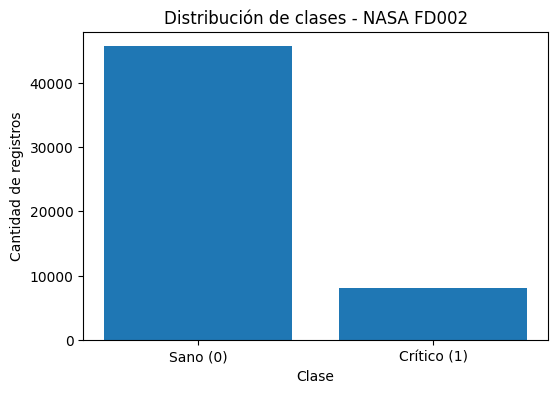

In [ ]:
# Graficar balance de clases

plt.figure(figsize=(6, 4))
plt.bar(["Sano (0)", "Crítico (1)"], class_counts.values)
plt.title("Distribución de clases - NASA FD002")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")
plt.show()

Este gráfico muestra que el dataset está desbalanceado: existen muchos más registros de motores sanos (Critico = 0) que registros de motores críticos (Critico = 1).

## 4. División interna en entrenamiento y validación

In [ ]:
# División train/validation por motor para evitar data leakage

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

train_engines = groups.iloc[train_idx]
val_engines = groups.iloc[val_idx]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

print("Motores en train:", train_engines.nunique())
print("Motores en validation:", val_engines.nunique())

overlap = set(train_engines.unique()).intersection(set(val_engines.unique()))
print("Motores repetidos entre train y validation:", len(overlap))

X_train: (43464, 27)
X_val: (10295, 27)
y_train: (43464,)
y_val: (10295,)
Motores en train: 208
Motores en validation: 52
Motores repetidos entre train y validation: 0


Se dividió el dataset en entrenamiento y validación usando GroupShuffleSplit, tomando como grupo a engine_id. Esto evita data leakage, ya que todos los ciclos de un mismo motor quedan completos en train o completos en validation, pero nunca en ambos conjuntos.

## 5. Normalización Z-score

In [ ]:
# Escalado Z-score usando solo los datos de entrenamiento

from sklearn.preprocessing import StandardScaler

X_test = test_df[feature_cols]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (43464, 27)
X_val_scaled: (10295, 27)
X_test_scaled: (33991, 27)


In [ ]:
# Convertir los datos escalados a DataFrame para mantener nombres de columnas

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns)
test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

X_train_scaled_df.head()

,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_mean,sensor_std,sensor_range
0,0.746154,0.864510,0.417443,-0.889101,-0.653572,-0.580393,-0.573879,-0.706407,-0.663270,-0.603022,...,0.022986,-0.707253,-0.516577,-0.040979,0.417443,-0.614412,-0.619602,-0.398104,-0.407923,-0.545663
1,1.220702,0.867089,0.417443,-1.057329,-0.798949,-0.631286,-0.669996,-1.140803,-1.084825,-0.987446,...,0.064789,-0.707253,-0.660724,-0.116750,0.417443,-1.052124,-1.048645,-0.535974,-0.398554,-0.658741
2,0.068252,0.161077,-2.395538,-0.392755,-1.136641,-1.542063,-1.327541,-0.272012,-0.475503,-0.732670,...,2.090395,-0.707253,-1.417495,-2.162563,-2.395538,-0.680271,-0.642366,-1.712096,-1.962344,-1.560210
3,1.221346,0.869668,0.417443,-1.057329,-0.809409,-0.623638,-0.664959,-1.140803,-1.084825,-0.987788,...,0.031935,-0.707253,-0.696761,-0.116750,0.417443,-1.033886,-1.014262,-0.538409,-0.407035,-0.658741
4,0.068368,0.156242,-2.395538,-0.392755,-1.143078,-1.533093,-1.323511,-0.272012,-0.473663,-0.737190,...,2.093333,-0.707253,-1.417495,-2.162563,-2.395538,-0.675205,-0.666633,-1.720333,-1.991461,-1.584613


In [ ]:
# Guardar archivos procesados para el siguiente avance

X_train_scaled_df.to_csv("X_train_scaled.csv", index=False)
X_val_scaled_df.to_csv("X_val_scaled.csv", index=False)
test_scaled_df.to_csv("test_scaled.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_val.to_csv("y_val.csv", index=False)

print("Archivos procesados guardados correctamente.")

Archivos procesados guardados correctamente.


## 6. Entrenamiento de modelos base

Se seleccionaron Logistic Regression, Linear SVM y Random Forest porque se ajustan bien a la naturaleza del problema y permiten comparar enfoques distintos de clasificación. El dataset contiene variables numéricas de sensores y condiciones operacionales, y la tarea consiste en predecir una etiqueta binaria: motor sano o crítico.

Logistic Regression se usa como modelo base, ya que permite estimar la probabilidad de que un motor pertenezca a la clase crítica. Además, es un modelo interpretable y se relaciona directamente con conceptos vistos en clase, como función sigmoide, threshold y Binary Cross-Entropy.

Linear SVM se incluye porque también es adecuado para clasificación binaria, pero a diferencia de Logistic Regression, busca una frontera de decisión que maximice el margen entre clases. Esto permite comparar dos modelos lineales con criterios de optimización distintos.

Finalmente, Random Forest se considera un modelo importante porque el comportamiento de los sensores puede involucrar relaciones no lineales e interacciones entre variables. Al ser un método de ensamble basado en árboles, puede capturar patrones más complejos y es menos dependiente de la normalización de los datos. Por ello, estos tres modelos ofrecen una comparación equilibrada entre interpretabilidad, separación lineal y capacidad para modelar relaciones más complejas.

In [ ]:
# Entrenar modelos base y evaluar con métricas de clasificación

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## 6.1. Modelo base 1: Logistic Regression

In [ ]:
# Modelo base 1: Logistic Regression

log_model = LogisticRegression(
    random_state=SEED,
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_val_scaled)

In [ ]:
# Evaluación de Logistic Regression

acc_log = accuracy_score(y_val, y_pred_log)
f1_log = f1_score(y_val, y_pred_log)

precision_log = precision_score(y_val, y_pred_log, zero_division=0)
recall_log = recall_score(y_val, y_pred_log, zero_division=0)

print("Logistic Regression")
print("Accuracy:", acc_log)
print("F1-score:", f1_log)

Logistic Regression
Accuracy: 0.9387081107333657
F1-score: 0.8271706381813202


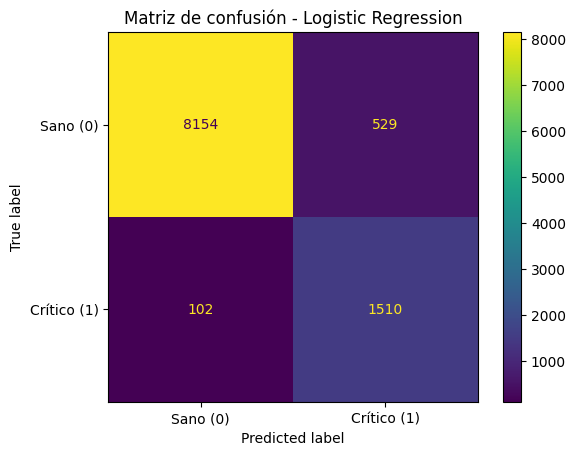

In [ ]:
# Matriz de confusión de Logistic Regression

cm_log = confusion_matrix(y_val, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Sano (0)", "Crítico (1)"]
)

disp.plot()
plt.title("Matriz de confusión - Logistic Regression")
plt.show()

## 6.2. Modelo base 2: Linear SVM

In [ ]:
# Modelo base 2: Linear SVM

svm_model = LinearSVC(
    random_state=SEED,
    class_weight="balanced",
    max_iter=5000
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_val_scaled)

In [ ]:
# Evaluación de Linear SVM

acc_svm = accuracy_score(y_val, y_pred_svm)
f1_svm = f1_score(y_val, y_pred_svm)

precision_svm = precision_score(y_val, y_pred_svm, zero_division=0)
recall_svm = recall_score(y_val, y_pred_svm, zero_division=0)

print("Linear SVM")
print("Accuracy:", acc_svm)
print("F1-score:", f1_svm)

Linear SVM
Accuracy: 0.9428848955803788
F1-score: 0.8375690607734807


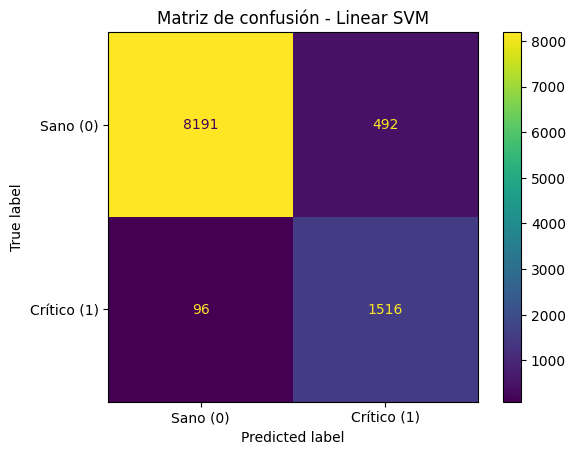

In [ ]:
# Matriz de confusión de Linear SVM

cm_svm = confusion_matrix(y_val, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Sano (0)", "Crítico (1)"]
)

disp.plot()
plt.title("Matriz de confusión - Linear SVM")
plt.show()

#6.3 Modelo base 3: Random forest

Random Forest
Accuracy: 0.9536668285575522
F1-score: 0.8605670856474715
Precision: 0.8137092316196793
Recall: 0.913151364764268


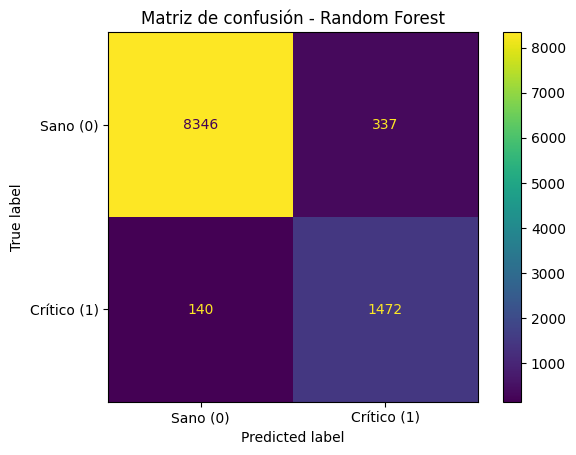

In [ ]:
# Modelo base 3: Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=SEED,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

# Evaluación de Random Forest

acc_rf = accuracy_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_val, y_pred_rf, zero_division=0)

print("Random Forest")
print("Accuracy:", acc_rf)
print("F1-score:", f1_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)

# Matriz de confusión de Random Forest

cm_rf = confusion_matrix(y_val, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Sano (0)", "Crítico (1)"]
)

disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

## 7. Comparación inicial de modelos

In [ ]:
# Comparación inicial de modelos

results_df = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Linear SVM", " Random Forest"],
    "Accuracy": [acc_log, acc_svm, acc_rf],
    "F1-score": [f1_log, f1_svm, f1_rf],
    "Precision": [precision_log, precision_svm, precision_rf],
    "Recall": [recall_log, recall_svm, recall_rf]
})

results_df

,Modelo,Accuracy,F1-score,Precision,Recall
0,Logistic Regression,0.938708,0.827171,0.740559,0.936725
1,Linear SVM,0.942885,0.837569,0.754980,0.940447
2,Random Forest,0.953667,0.860567,0.813709,0.913151


In [ ]:
train_df.columns

Index(['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'Critico',
       'sensor_mean', 'sensor_std', 'sensor_range'],
      dtype='object')

## 7.1 Comparación de modelos con y sin normalización

In [ ]:
# Comparación de modelos con distintos tipos de normalización

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.base import clone

scalers = {
    "Sin normalización": None,
    "Z-score": StandardScaler(),
    "MinMax": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

models_for_scaling = {
    "Logistic Regression": LogisticRegression(
        random_state=SEED,
        max_iter=3000,
        class_weight="balanced"
    ),
    "Linear SVM": LinearSVC(
        random_state=SEED,
        class_weight="balanced",
        max_iter=10000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        random_state=SEED,
        class_weight="balanced_subsample",
        n_jobs=-1
    )
}

normalization_results = []

for scaler_name, scaler_exp in scalers.items():

    if scaler_exp is None:
        X_train_exp = X_train
        X_val_exp = X_val
    else:
        X_train_exp = scaler_exp.fit_transform(X_train)
        X_val_exp = scaler_exp.transform(X_val)

    for model_name, model in models_for_scaling.items():

        model_exp = clone(model)

        model_exp.fit(X_train_exp, y_train)
        y_pred_exp = model_exp.predict(X_val_exp)

        normalization_results.append({
            "Modelo": model_name,
            "Normalización": scaler_name,
            "Accuracy": accuracy_score(y_val, y_pred_exp),
            "F1-score": f1_score(y_val, y_pred_exp),
            "Precision": precision_score(y_val, y_pred_exp, zero_division=0),
            "Recall": recall_score(y_val, y_pred_exp, zero_division=0)
        })

normalization_results_df = pd.DataFrame(normalization_results)

normalization_results_df.sort_values(
    by="F1-score",
    ascending=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Modelo,Normalización,Accuracy,F1-score,Precision,Recall
5,Random Forest,Z-score,0.953667,0.860567,0.813709,0.913151
11,Random Forest,RobustScaler,0.952890,0.858229,0.811498,0.910670
8,Random Forest,MinMax,0.952793,0.858144,0.810364,0.911911
2,Random Forest,Sin normalización,0.952695,0.857893,0.809917,0.911911
1,Linear SVM,Sin normalización,0.944245,0.840821,0.760281,0.940447
4,Linear SVM,Z-score,0.942885,0.837569,0.754980,0.940447
10,Linear SVM,RobustScaler,0.942011,0.835310,0.752111,0.939206
7,Linear SVM,MinMax,0.938514,0.827191,0.738664,0.939826
3,Logistic Regression,Z-score,0.938708,0.827171,0.740559,0.936725
9,Logistic Regression,RobustScaler,0.936960,0.823305,0.733624,0.937965


Random Forest obtiene los mejores resultados en todos los escenarios, con un F1-score máximo de 0.863477 usando RobustScaler. Sin embargo, sus métricas cambian muy poco entre normalizaciones, lo que confirma que este modelo no depende mucho del escalado.

Logistic Regression sí mejora claramente con normalización: sin normalizar tiene el peor F1-score (0.759408), mientras que con Z-score sube a 0.827171. Esto muestra que los modelos lineales son más sensibles a la escala de las variables.

Aunque la literatura y la documentación de scikit-learn recomiendan escalar los datos para SVM, en este conjunto de validación la versión sin normalización obtuvo un F1-score ligeramente superior. Debido a que la diferencia frente a Z-score fue pequeña, se considera que ambas configuraciones presentan un desempeño similar, pero se reporta la configuración con mejor F1-score observado.

## 8. Ordenar la tabla de modelos por F1-score

In [ ]:
# Ordenar modelos base por F1-score

results_df_sorted = results_df.sort_values(
    by="F1-score",
    ascending=False
)

results_df_sorted

,Modelo,Accuracy,F1-score,Precision,Recall
2,Random Forest,0.953667,0.860567,0.813709,0.913151
1,Linear SVM,0.942885,0.837569,0.754980,0.940447
0,Logistic Regression,0.938708,0.827171,0.740559,0.936725


## Bias-Variance Tradeoff

In [ ]:
# Comparación train vs validation

bias_variance_results = []

models_bias_variance = {
    "Logistic Regression": (log_model, X_train_scaled, X_val_scaled),
    "Linear SVM": (svm_model, X_train_scaled, X_val_scaled),
    "Random Forest": (rf_model, X_train, X_val)
}

for model_name, (model, X_tr, X_va) in models_bias_variance.items():

    y_train_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_va)

    f1_train = f1_score(y_train, y_train_pred)
    f1_val = f1_score(y_val, y_val_pred)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_val = accuracy_score(y_val, y_val_pred)

    bias_variance_results.append({
        "Modelo": model_name,
        "F1 Train": f1_train,
        "F1 Validation": f1_val,
        "Diferencia F1": f1_train - f1_val,
        "Accuracy Train": acc_train,
        "Accuracy Validation": acc_val,
        "Diferencia Accuracy": acc_train - acc_val
    })

bias_variance_df = pd.DataFrame(bias_variance_results)

bias_variance_df

,Modelo,F1 Train,F1 Validation,Diferencia F1,Accuracy Train,Accuracy Validation,Diferencia Accuracy
0,Logistic Regression,0.790452,0.827171,-0.036719,0.926077,0.938708,-0.012631
1,Linear SVM,0.796701,0.837569,-0.040868,0.928539,0.942885,-0.014346
2,Random Forest,0.885313,0.860567,0.024746,0.962452,0.953667,0.008785


Logistic Regression tiene F1 en train de 0.7905 y F1 en validation de 0.8272. Como validation sale incluso mejor que train, no hay señal de overfitting. Esto puede pasar por la forma en que se dividieron los motores o por el efecto del desbalance. El modelo parece estable, aunque no es el más potente.

Linear SVM muestra algo similar: F1 en train de 0.7967 y F1 en validation de 0.8376. Tampoco hay evidencia de sobreajuste. El modelo generaliza bien y mantiene un desempeño parecido entre entrenamiento y validación.

Random Forest tiene F1 en train de 0.8853 y F1 en validation de 0.8606. Aquí sí el train es un poco mayor que validation, lo cual es normal en modelos más flexibles. La diferencia es de aproximadamente 0.0247, que no es muy grande, por lo que no parece haber overfitting severo.

## 9. Cross-Validation estratificada por grupos

In [ ]:
# Cross-Validation estratificada por motor

from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

## 10. Optimización de hiperparámetros con RandomizedSearchCV

In [ ]:
# Optimización de hiperparámetros

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

## 10.1. Optimización de Logistic Regression

In [ ]:
# Pipeline para Logistic Regression: escalado + modelo

log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=SEED,
        max_iter=3000,
        class_weight="balanced"
    ))
])

param_dist_log = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

random_log = RandomizedSearchCV(
    estimator=log_pipeline,
    param_distributions=param_dist_log,
    n_iter=6,
    scoring="f1",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

random_log.fit(X_train, y_train, groups=train_engines)

print("Mejores parámetros Logistic Regression:")
print(random_log.best_params_)
print("Mejor F1 en Cross-Validation:", random_log.best_score_)

Mejores parámetros Logistic Regression:
{'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 100}
Mejor F1 en Cross-Validation: 0.8010963702260216


In [ ]:
# Mostrar resultados de Cross-Validation para Logistic Regression en tabla

log_results_df = pd.DataFrame(random_log.cv_results_)

log_results_table = log_results_df[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_model__C",
    "param_model__penalty",
    "param_model__solver"
]].sort_values("rank_test_score")

log_results_table

,rank_test_score,mean_test_score,std_test_score,param_model__C,param_model__penalty,param_model__solver
5,1,0.801096,0.013204,100.000,l2,lbfgs
4,2,0.797255,0.011845,10.000,l2,lbfgs
3,3,0.790883,0.012893,1.000,l2,lbfgs
2,4,0.774507,0.014827,0.100,l2,lbfgs
1,5,0.718409,0.011024,0.010,l2,lbfgs
0,6,0.543485,0.021578,0.001,l2,lbfgs


El mejor resultado de Logistic Regression se obtuvo con C = 100, alcanzando un F1 promedio en Cross-Validation de 0.8012. Esto indica que, dentro de los valores probados, el modelo tuvo mejor desempeño cuando se redujo la fuerza de la regularización.

En Logistic Regression, el parámetro C controla la regularización de manera inversa: valores pequeños de C aplican más regularización y hacen que el modelo sea más simple, mientras que valores grandes de C aplican menos regularización y permiten que el modelo sea más flexible. En la tabla se observa que el F1-score aumenta conforme crece C, pasando de 0.5447 con C = 0.001 a 0.8012 con C = 100. Esto sugiere que una regularización demasiado fuerte limita la capacidad del modelo para separar correctamente los motores sanos y críticos.

Se mantuvo penalty="l2" porque es una regularización estándar en Logistic Regression y ayuda a evitar pesos excesivamente grandes. También se mantuvo solver="lbfgs" porque es un optimizador adecuado para este tipo de modelo con regularización L2. En conclusión, esta prueba permitió identificar que Logistic Regression necesita un nivel bajo de regularización para obtener un mejor equilibrio entre precision y recall, medido mediante el F1-score.

## 10.2. Optimización de SVM

In [ ]:
# Optimización de Linear SVM

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(
        random_state=SEED,
        class_weight="balanced",
        max_iter=5000
    ))
])

param_dist_svm = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

random_svm = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_dist_svm,
    n_iter=6,
    scoring="f1",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

random_svm.fit(X_train, y_train, groups=train_engines)

print("Mejores parámetros Linear SVM:")
print(random_svm.best_params_)
print("Mejor F1 en Cross-Validation:", random_svm.best_score_)

Mejores parámetros Linear SVM:
{'model__C': 100}
Mejor F1 en Cross-Validation: 0.8025752961227148


In [ ]:
# Mostrar resultados de Cross-Validation para Linear SVM en tabla

svm_results_df = pd.DataFrame(random_svm.cv_results_)

svm_results_table = svm_results_df[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_model__C"
]].sort_values("rank_test_score")

svm_results_table = svm_results_table.rename(columns={
    "rank_test_score": "Ranking",
    "mean_test_score": "F1 promedio CV",
    "std_test_score": "Desviación F1",
    "param_model__C": "C"
})

svm_results_table["F1 promedio CV"] = svm_results_table["F1 promedio CV"].round(4)
svm_results_table["Desviación F1"] = svm_results_table["Desviación F1"].round(4)

svm_results_table

,Ranking,F1 promedio CV,Desviación F1,C
5,1,0.8026,0.0148,100.000
4,2,0.8016,0.0142,10.000
3,3,0.7962,0.0130,1.000
2,4,0.7900,0.0130,0.100
1,5,0.7726,0.0146,0.010
0,6,0.7180,0.0111,0.001


El mejor resultado de Linear SVM se obtiene con el valor de C que alcanza el mayor F1 promedio en Cross-Validation. En SVM, el parámetro C controla la penalización de los errores de clasificación. Un valor pequeño de C permite un margen más amplio y acepta más errores, mientras que un valor grande de C penaliza más los errores y busca una frontera de decisión más ajustada a los datos.

Se probó el parámetro C porque es el hiperparámetro más importante en Linear SVM para controlar el equilibrio entre margen y errores. Además, se utilizó class_weight="balanced" debido al desbalance entre motores sanos y críticos.

## 10.3. Optimización de Random Forest

In [ ]:
# Optimización Random Forest

param_dist_rf = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3],
    "class_weight": ["balanced"]
}

random_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

random_rf.fit(X_train, y_train, groups=train_engines)

print("Mejores parámetros Random Forest:")
print(random_rf.best_params_)
print("Mejor F1 en Cross-Validation:", random_rf.best_score_)

'''
Mejores parámetros Random Forest:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_depth': None, 'class_weight': 'balanced'}
Mejor F1 en Cross-Validation: 0.8435203837629747
'''

Mejores parámetros Random Forest:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_depth': None, 'class_weight': 'balanced'}
Mejor F1 en Cross-Validation: 0.8435203837629747


"\nMejores parámetros Random Forest:\n{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_depth': None, 'class_weight': 'balanced'}\nMejor F1 en Cross-Validation: 0.8441621634313778\n"

In [ ]:
# Mostrar resultados de Cross-Validation para Random Forest en tabla

rf_results_df = pd.DataFrame(random_rf.cv_results_)

rf_results_table = rf_results_df[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_class_weight"
]].sort_values("rank_test_score")

rf_results_table = rf_results_table.rename(columns={
    "rank_test_score": "Ranking",
    "mean_test_score": "F1 promedio CV",
    "std_test_score": "Desviación F1",
    "param_n_estimators": "n_estimators",
    "param_max_depth": "max_depth",
    "param_min_samples_split": "min_samples_split",
    "param_min_samples_leaf": "min_samples_leaf",
    "param_class_weight": "class_weight"
})

rf_results_table["F1 promedio CV"] = rf_results_table["F1 promedio CV"].round(4)
rf_results_table["Desviación F1"] = rf_results_table["Desviación F1"].round(4)

rf_results_table

,Ranking,F1 promedio CV,Desviación F1,n_estimators,max_depth,min_samples_split,min_samples_leaf,class_weight
0,1,0.8435,0.0076,200,None,2,3,balanced
6,2,0.8431,0.0070,100,None,5,3,balanced
3,3,0.8419,0.0123,200,16,2,1,balanced
7,4,0.8385,0.0152,200,None,2,1,balanced
4,5,0.8367,0.0081,100,12,2,1,balanced
2,6,0.8366,0.0164,100,None,2,1,balanced
5,7,0.8361,0.0086,200,12,2,1,balanced
1,8,0.8359,0.0067,200,12,5,3,balanced
8,9,0.8340,0.0079,100,12,2,3,balanced
9,10,0.8113,0.0103,100,8,2,1,balanced


Para Random Forest, el mejor resultado se obtuvo con:

n_estimators = 100
max_depth = None
min_samples_split = 5
min_samples_leaf = 3
class_weight = balanced
F1 promedio CV = 0.8442

Esto indica que el modelo funcionó mejor usando árboles sin límite máximo de profundidad, pero con restricciones en la división y en las hojas. Es decir, aunque los árboles pueden crecer libremente, min_samples_split = 5 y min_samples_leaf = 3 evitan que el modelo cree divisiones demasiado específicas con muy pocos datos, reduciendo el riesgo de sobreajuste.

También se observa que las mejores configuraciones usan max_depth = None o valores relativamente altos, lo que sugiere que el problema necesita árboles con suficiente profundidad para capturar relaciones complejas entre sensores. El uso de class_weight = balanced se mantiene porque el dataset está desbalanceado y la clase crítica tiene menor proporción.

## 11. Comparar modelos optimizados

In [ ]:
hyperparams_summary_df = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest"
    ],
    "Hiperparámetros explorados": [
        "C, penalty, solver",
        "C",
        "n_estimators, max_depth, min_samples_split, min_samples_leaf, class_weight"
    ],
    "Mejores hiperparámetros": [
        random_log.best_params_,
        random_svm.best_params_,
        random_rf.best_params_
    ],
    "Mejor F1 CV": [
        random_log.best_score_,
        random_svm.best_score_,
        random_rf.best_score_
    ]
})

hyperparams_summary_df

,Modelo,Hiperparámetros explorados,Mejores hiperparámetros,Mejor F1 CV
0,Logistic Regression,"C, penalty, solver","{'model__solver': 'lbfgs', 'model__penalty': '...",0.801096
1,Linear SVM,C,{'model__C': 100},0.802575
2,Random Forest,"n_estimators, max_depth, min_samples_split, mi...","{'n_estimators': 200, 'min_samples_split': 2, ...",0.843520


## 12. Evaluar el mejor modelo optimizado en validation

In [ ]:
# Evaluar modelos optimizados en validation

optimized_models = {
    "Logistic Regression": random_log.best_estimator_,
    "Linear SVM": random_svm.best_estimator_,
    "Random Forest": random_rf.best_estimator_
}

validation_results = []

for model_name, model in optimized_models.items():
    y_pred = model.predict(X_val)

    validation_results.append({
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0)
    })

validation_results_df = pd.DataFrame(validation_results)

validation_results_df = validation_results_df.sort_values(
    by="F1-score",
    ascending=False
)

validation_results_df

,Modelo,Accuracy,F1-score,Precision,Recall
2,Random Forest,0.958815,0.868077,0.870787,0.865385
1,Linear SVM,0.944148,0.840233,0.760946,0.937965
0,Logistic Regression,0.943371,0.838638,0.757121,0.939826


## 12.1. Seleccionar mejor modelo optimizado en validation

In [ ]:
# Seleccionar mejor modelo optimizado según F1-score en validation

best_model_name = validation_results_df.iloc[0]["Modelo"]
best_model = optimized_models[best_model_name]

print("Mejor modelo optimizado en validation:", best_model_name)

y_pred_best = best_model.predict(X_val)

acc_best = accuracy_score(y_val, y_pred_best)
f1_best = f1_score(y_val, y_pred_best)
precision_best = precision_score(y_val, y_pred_best, zero_division=0)
recall_best = recall_score(y_val, y_pred_best, zero_division=0)

print("Accuracy:", acc_best)
print("F1-score:", f1_best)
print("Precision:", precision_best)
print("Recall:", recall_best)

Mejor modelo optimizado en validation: Random Forest
Accuracy: 0.9588149587178242
F1-score: 0.8680771624144369
Precision: 0.8707865168539326
Recall: 0.8653846153846154


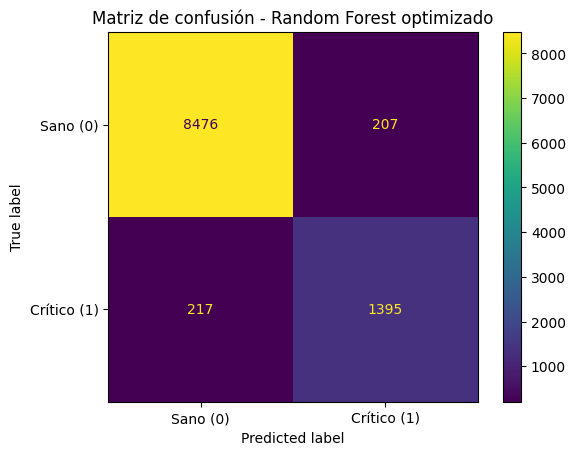

In [ ]:
# Matriz de confusión del mejor modelo optimizado

cm_best = confusion_matrix(y_val, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["Sano (0)", "Crítico (1)"]
)

disp.plot()
plt.title(f"Matriz de confusión - {best_model_name} optimizado")
plt.show()

## 13. Seleccionar modelo para threshold

In [ ]:
# Seleccionar mejor modelo con predict_proba para optimización de threshold

probabilistic_models = {
    "Logistic Regression": random_log.best_estimator_,
    "Random Forest": random_rf.best_estimator_
}

probabilistic_results = validation_results_df[
    validation_results_df["Modelo"].isin(probabilistic_models.keys())
].sort_values(
    by="F1-score",
    ascending=False
)

threshold_model_name = probabilistic_results.iloc[0]["Modelo"]
threshold_model = probabilistic_models[threshold_model_name]

print("Modelo usado para threshold:", threshold_model_name)

y_val_proba = threshold_model.predict_proba(X_val)[:, 1]

Modelo usado para threshold: Random Forest


## 13.1. Optimización del threshold por F1-score

In [ ]:
# Probar varios thresholds

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_val_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, y_pred_threshold),
        "F1-score": f1_score(y_val, y_pred_threshold),
        "Precision": precision_score(y_val, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_val, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    by="F1-score",
    ascending=False
).head(10)

,Threshold,Accuracy,F1-score,Precision,Recall
37,0.47,0.958912,0.869886,0.862721,0.877171
34,0.44,0.958232,0.869539,0.850950,0.888958
35,0.45,0.958426,0.869512,0.854916,0.884615
33,0.43,0.957941,0.869224,0.846969,0.892680
38,0.48,0.958815,0.869055,0.865314,0.872829
39,0.49,0.958912,0.868919,0.868111,0.869727
36,0.46,0.958232,0.868421,0.856884,0.880273
40,0.50,0.958815,0.868077,0.870787,0.865385
41,0.51,0.958815,0.867500,0.874055,0.861042
32,0.42,0.956969,0.867087,0.839628,0.896402


In [ ]:
# Seleccionar threshold con mejor F1-score

best_threshold_f1 = threshold_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["Threshold"]

print("Mejor threshold según F1-score:", best_threshold_f1)

Mejor threshold según F1-score: 0.46999999999999986


## 14. Matriz de costos

In [ ]:
# Definir costos

COST_FP = 1000
COST_FN = 10000

In [ ]:
# Calcular costo total para cada threshold

cost_results = []

for threshold in thresholds:
    y_pred_threshold = (y_val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_threshold).ravel()

    total_cost = (fp * COST_FP) + (fn * COST_FN)

    cost_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Costo total": total_cost,
        "F1-score": f1_score(y_val, y_pred_threshold),
        "Precision": precision_score(y_val, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_val, y_pred_threshold, zero_division=0)
    })

cost_df = pd.DataFrame(cost_results)

cost_df.sort_values(
    by="Costo total",
    ascending=True
).head(10)

,Threshold,TN,FP,FN,TP,Costo total,F1-score,Precision,Recall
4,0.14,7837,846,29,1583,1136000,0.783469,0.651709,0.982010
5,0.15,7877,806,35,1577,1156000,0.789487,0.661771,0.978288
3,0.13,7800,883,28,1584,1163000,0.776661,0.642075,0.982630
6,0.16,7912,771,41,1571,1181000,0.794638,0.670794,0.974566
8,0.18,7970,713,48,1564,1193000,0.804320,0.686869,0.970223
10,0.20,8036,647,55,1557,1197000,0.816038,0.706443,0.965881
2,0.12,7743,940,26,1586,1200000,0.766554,0.627870,0.983871
7,0.17,7940,743,46,1566,1203000,0.798776,0.678216,0.971464
9,0.19,8007,676,53,1559,1206000,0.810502,0.697539,0.967122
1,0.11,7694,989,24,1588,1229000,0.758176,0.616220,0.985112


In [ ]:
# Seleccionar threshold con menor costo total

best_threshold_cost = cost_df.sort_values(
    by="Costo total",
    ascending=True
).iloc[0]["Threshold"]

print("Mejor threshold según costo total:", best_threshold_cost)

Mejor threshold según costo total: 0.13999999999999999


Con un threshold bajo como 0.14, el modelo clasifica más motores como críticos. Esto aumenta los falsos positivos (FP = 846), es decir, motores sanos marcados como críticos, pero reduce mucho los falsos negativos (FN = 29), que son los errores más peligrosos: motores críticos clasificados como sanos. Por eso el recall es muy alto:

Recall = 0.982010

Esto significa que el modelo detecta aproximadamente el 98.2% de los motores críticos reales.

Aunque el F1-score no es el máximo posible, este threshold minimiza el costo total porque en la matriz de costos se está penalizando mucho más el falso negativo que el falso positivo.

## 14.1. Gráfico threshold vs F1-score y costo

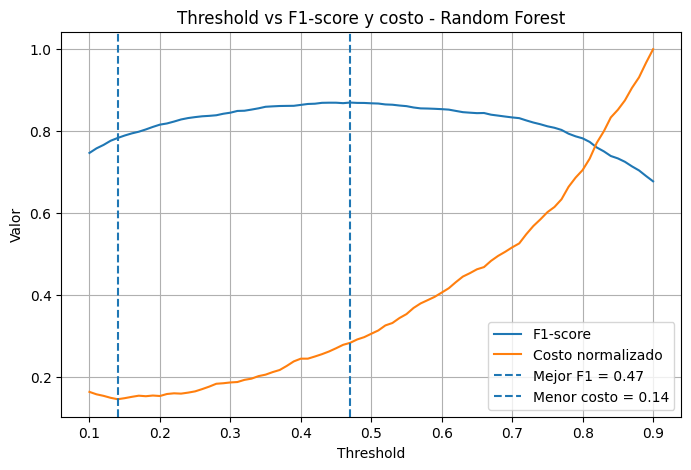

In [ ]:
# Comparación visual entre F1-score y costo total

cost_df_plot = cost_df.copy()
cost_df_plot["Costo normalizado"] = cost_df_plot["Costo total"] / cost_df_plot["Costo total"].max()

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    label="F1-score"
)

plt.plot(
    cost_df_plot["Threshold"],
    cost_df_plot["Costo normalizado"],
    label="Costo normalizado"
)

plt.axvline(
    best_threshold_f1,
    linestyle="--",
    label=f"Mejor F1 = {best_threshold_f1:.2f}"
)

plt.axvline(
    best_threshold_cost,
    linestyle="--",
    label=f"Menor costo = {best_threshold_cost:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Valor")
plt.title(f"Threshold vs F1-score y costo - {threshold_model_name}")
plt.legend()
plt.grid(True)
plt.show()

La línea azul representa el F1-score. Se observa que el F1 mejora al aumentar el threshold desde 0.10 hasta aproximadamente 0.47, donde alcanza su mejor valor. Después de ese punto, el F1-score empieza a bajar. Esto significa que un threshold muy bajo genera demasiadas alertas críticas, mientras que un threshold muy alto deja de detectar suficientes motores críticos.

La línea naranja representa el costo normalizado. El costo mínimo aparece con un threshold aproximado de 0.14. Esto ocurre porque, al usar un umbral bajo, el modelo clasifica más motores como críticos, reduciendo los falsos negativos. En mantenimiento predictivo, esto es importante porque un falso negativo —decir que un motor está sano cuando en realidad está crítico— suele ser mucho más costoso que una falsa alarma.

Entonces, hay dos posibles decisiones:



*   Si se prioriza el mejor equilibrio estadístico, se usaría el threshold de 0.47, porque maximiza el F1-score.

*   Si se prioriza reducir el costo económico de errores, se usaría el threshold de 0.14, porque minimiza el costo total.

## 15. Evaluación final usando threshold seleccionado por costo

In [ ]:
# Evaluación final con el threshold seleccionado por matriz de costos

final_model_name = threshold_model_name
final_model = threshold_model
final_threshold = best_threshold_cost

y_pred_final = (y_val_proba >= final_threshold).astype(int)

acc_final = accuracy_score(y_val, y_pred_final)
f1_final = f1_score(y_val, y_pred_final)
precision_final = precision_score(y_val, y_pred_final, zero_division=0)
recall_final = recall_score(y_val, y_pred_final, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_val, y_pred_final).ravel()
total_cost_final = (fp * COST_FP) + (fn * COST_FN)

print("Modelo final usado para threshold:", final_model_name)
print("Threshold final:", final_threshold)
print("Accuracy:", acc_final)
print("F1-score:", f1_final)
print("Precision:", precision_final)
print("Recall:", recall_final)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)
print("Costo total final:", total_cost_final)

Modelo final usado para threshold: Random Forest
Threshold final: 0.13999999999999999
Accuracy: 0.9150072850898494
F1-score: 0.783469438257857
Precision: 0.6517085220255249
Recall: 0.9820099255583127
TN: 7837
FP: 846
FN: 29
TP: 1583
Costo total final: 1136000


In [ ]:
final_summary_df = validation_results_df.copy()

final_summary_df = pd.concat([
    final_summary_df,
    pd.DataFrame([{
        "Modelo": f"{final_model_name} + threshold costo",
        "Accuracy": acc_final,
        "F1-score": f1_final,
        "Precision": precision_final,
        "Recall": recall_final
    }])
], ignore_index=True)

final_summary_df = final_summary_df.sort_values(
    by="F1-score",
    ascending=False
)

final_summary_df

,Modelo,Accuracy,F1-score,Precision,Recall
0,Random Forest,0.958815,0.868077,0.870787,0.865385
1,Linear SVM,0.944148,0.840233,0.760946,0.937965
2,Logistic Regression,0.943371,0.838638,0.757121,0.939826
3,Random Forest + threshold costo,0.915007,0.783469,0.651709,0.982010


## 15.1. Matriz de confusión final

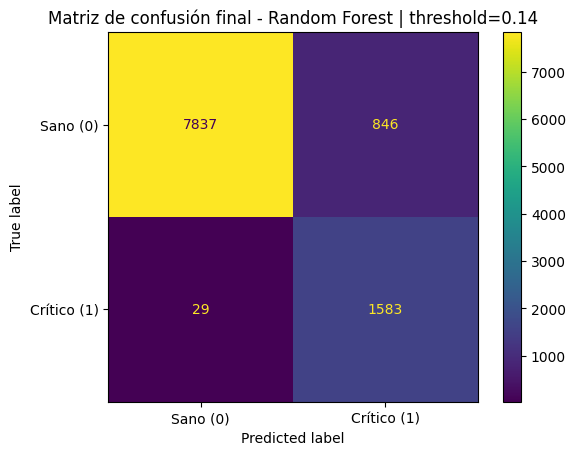

In [ ]:
# Matriz de confusión final

cm_final = confusion_matrix(y_val, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Sano (0)", "Crítico (1)"]
)

disp.plot()
plt.title(f"Matriz de confusión final - {final_model_name} | threshold={final_threshold:.2f}")
plt.show()

## 16. Actividad Kaggle

In [ ]:
# Cargar sample_submission para respetar el formato de Kaggle
sample_submission = pd.read_csv("sample_submission.csv")

print(sample_submission.head())
print(sample_submission.shape)
print(sample_submission.columns)

   engine_id  Critico
0          1        0
1          2        0
2          3        0
3          4        0
4          5        0
(259, 2)
Index(['engine_id', 'Critico'], dtype='object')


In [ ]:
# Tomar la última fila disponible de cada motor en test
test_last = test_df.sort_values(["engine_id", "cycle"]).groupby("engine_id").tail(1)

# Asegurar mismo orden que sample_submission
test_last = test_last.set_index("engine_id").loc[sample_submission["engine_id"]].reset_index()

# Features del test
X_test_last = test_last[feature_cols]

# Probabilidad de clase crítica
test_proba = threshold_model.predict_proba(X_test_last)[:, 1]

# Convertir probabilidad a clase usando el threshold final
test_pred = (test_proba >= final_threshold).astype(int)

# Crear submission con el mismo formato del sample_submission
submission = sample_submission.copy()
submission["Critico"] = test_pred

submission.to_csv("submission.csv", index=False)

submission.head()

,engine_id,Critico
0,1,1
1,2,0
2,3,0
3,4,0
4,5,1


In [ ]:
print(submission.shape)
print(submission.columns)
print(submission["Critico"].value_counts())

(259, 2)
Index(['engine_id', 'Critico'], dtype='object')
Critico
0    170
1     89
Name: count, dtype: int64
